# Training: BioLeakyRNN on CuedTarget V3

Stage 0 → 1 → 2 curriculum.  V3 obs: (7,) with continuous spatial coords.

In [ ]:
import sys
sys.path.insert(0, '..')

import torch
import matplotlib.pyplot as plt
from pathlib import Path

from src import BioLeakyRNN, CuedTargetWithDistractorsV3, TrainConfig, train_supervised

device = 'cpu'
print('device:', device)
Path('../checkpoints').mkdir(exist_ok=True)

In [2]:
def make_model():
    return BioLeakyRNN(
        input_size=7, hidden_size=128, output_size=2,
        dt=20.0, tau=100.0, activation='softplus', sigma_rec=0.05,
        rec_init='diag', use_ei=True, exc_ratio=0.7, use_dale=True,
        mask_seed=42,
    ).to(device)

## Stage 0 — detect target, no cue, no distractors

In [3]:
def make_env_stage0():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=0.0,
                                       p_distractor_trial=0.0, distractor_strength=0.0)

model = make_model()
cfg0 = TrainConfig(
    batch_size=64, lr=1e-3, max_updates=1000,
    print_every=50, device=device,
    stop_on_no_miss=0,  # на stage 0 miss норма, не останавливаем
)
history0 = train_supervised(model, make_env_stage0, cfg0)
torch.save({'state_dict': model.state_dict()}, '../checkpoints/stage0.pt')

C:\Users\savoj\projects\leaky-rnn-dale\notebooks\..\src\training.py:148: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  history["loss"].append(float(loss))


Upd     1/1000 | Loss 1654002024448.0000 | CE 13349892.0000 | Reg 1653988655104.0000 | p_abort 0.00  p_miss 1.00  p_corr 0.00
Upd    50/1000 | Loss 0.2740 | CE 0.2740 | Reg 0.0000 | p_abort 0.00  p_miss 1.00  p_corr 0.00
Upd   100/1000 | Loss 0.2020 | CE 0.2020 | Reg 0.0000 | p_abort 0.14  p_miss 0.77  p_corr 0.09
Upd   150/1000 | Loss 0.2671 | CE 0.2671 | Reg 0.0000 | p_abort 0.00  p_miss 1.00  p_corr 0.00
Upd   200/1000 | Loss 0.1295 | CE 0.1295 | Reg 0.0000 | p_abort 0.53  p_miss 0.08  p_corr 0.39
Upd   250/1000 | Loss 0.1492 | CE 0.1492 | Reg 0.0000 | p_abort 0.22  p_miss 0.25  p_corr 0.53
Upd   300/1000 | Loss 0.0462 | CE 0.0462 | Reg 0.0000 | p_abort 0.53  p_miss 0.00  p_corr 0.47
Upd   350/1000 | Loss 0.0282 | CE 0.0282 | Reg 0.0000 | p_abort 0.47  p_miss 0.00  p_corr 0.53
Upd   400/1000 | Loss 0.0213 | CE 0.0213 | Reg 0.0000 | p_abort 0.41  p_miss 0.00  p_corr 0.59
Upd   450/1000 | Loss 0.0191 | CE 0.0191 | Reg 0.0000 | p_abort 0.12  p_miss 0.00  p_corr 0.88
Upd   500/1000 | Lo

KeyboardInterrupt: 

## Stage 1 — add cue

In [4]:
def make_env_stage1():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=1.0,
                                       p_distractor_trial=0.0, distractor_strength=0.0)

model = make_model()
model.load_state_dict(torch.load('../checkpoints/stage0.pt', weights_only=True)['state_dict'])
cfg1 = TrainConfig(
    batch_size=64, lr=1e-3, max_updates=1000,
    print_every=50, device=device,
    stop_on_no_miss=0,  # на stage 1 тоже
)
history1 = train_supervised(model, make_env_stage1, cfg1)
torch.save({'state_dict': model.state_dict()}, '../checkpoints/stage1.pt')

C:\Users\savoj\projects\leaky-rnn-dale\.venv\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Upd     1/1000 | Loss 0.0135 | CE 0.0135 | Reg 0.0000 | p_abort 0.72  p_miss 0.00  p_corr 0.28
Upd    50/1000 | Loss 0.0152 | CE 0.0152 | Reg 0.0000 | p_abort 0.25  p_miss 0.00  p_corr 0.75
Upd   100/1000 | Loss 0.0113 | CE 0.0112 | Reg 0.0000 | p_abort 0.19  p_miss 0.00  p_corr 0.81
Upd   150/1000 | Loss 0.0122 | CE 0.0122 | Reg 0.0000 | p_abort 0.06  p_miss 0.00  p_corr 0.94
Upd   200/1000 | Loss 0.0142 | CE 0.0141 | Reg 0.0000 | p_abort 0.25  p_miss 0.00  p_corr 0.75
Upd   250/1000 | Loss 0.0097 | CE 0.0097 | Reg 0.0000 | p_abort 0.25  p_miss 0.00  p_corr 0.75
Upd   300/1000 | Loss 0.0099 | CE 0.0099 | Reg 0.0000 | p_abort 0.31  p_miss 0.00  p_corr 0.69
Upd   350/1000 | Loss 0.0115 | CE 0.0115 | Reg 0.0000 | p_abort 0.64  p_miss 0.00  p_corr 0.36
Upd   400/1000 | Loss 0.0105 | CE 0.0104 | Reg 0.0000 | p_abort 0.00  p_miss 0.00  p_corr 1.00
Upd   450/1000 | Loss 0.0073 | CE 0.0072 | Reg 0.0000 | p_abort 0.03  p_miss 0.00  p_corr 0.97
Upd   500/1000 | Loss 0.0077 | CE 0.0076 | Reg 0.0

## Stage 2 — cue + distractors

In [7]:
def make_env_stage2():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=1.0,
                                       p_distractor_trial=0.6, distractor_strength=1.0)

model = make_model()
model.load_state_dict(torch.load('../checkpoints/stage1.pt', weights_only=True)['state_dict'])
cfg2 = TrainConfig(
    batch_size=64, lr=1e-3, max_updates=12000,
    print_every=50, device=device,
)  # early stopping включён (дефолт stop_on_no_miss=3)
history2 = train_supervised(model, make_env_stage2, cfg2)
torch.save({'state_dict': model.state_dict()}, '../checkpoints/stage2.pt')

Upd     1/12000 | Loss 2.6768 | CE 2.6767 | Reg 0.0001 | p_abort 0.61  p_miss 0.00  p_corr 0.39
Upd    50/12000 | Loss 0.2263 | CE 0.2263 | Reg 0.0000 | p_abort 0.59  p_miss 0.00  p_corr 0.41
Upd   100/12000 | Loss 0.1546 | CE 0.1546 | Reg 0.0000 | p_abort 0.34  p_miss 0.05  p_corr 0.61
Upd   150/12000 | Loss 0.1259 | CE 0.1259 | Reg 0.0000 | p_abort 0.06  p_miss 0.23  p_corr 0.70
Upd   200/12000 | Loss 0.0987 | CE 0.0987 | Reg 0.0000 | p_abort 0.48  p_miss 0.08  p_corr 0.44
Upd   250/12000 | Loss 0.0850 | CE 0.0850 | Reg 0.0000 | p_abort 0.05  p_miss 0.11  p_corr 0.84
Upd   300/12000 | Loss 0.0898 | CE 0.0897 | Reg 0.0000 | p_abort 0.30  p_miss 0.06  p_corr 0.64
Upd   350/12000 | Loss 0.1059 | CE 0.1059 | Reg 0.0000 | p_abort 0.47  p_miss 0.03  p_corr 0.50
Upd   400/12000 | Loss 0.0715 | CE 0.0715 | Reg 0.0000 | p_abort 0.33  p_miss 0.02  p_corr 0.66
Upd   450/12000 | Loss 0.0919 | CE 0.0919 | Reg 0.0000 | p_abort 0.23  p_miss 0.03  p_corr 0.73
Upd   500/12000 | Loss 0.0699 | CE 0.069

KeyboardInterrupt: 

## Training curves

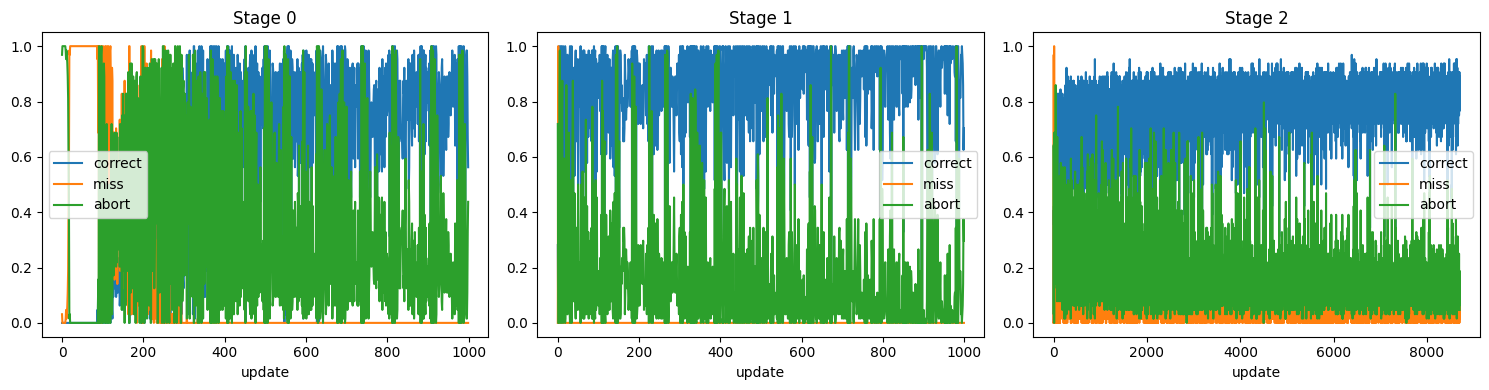

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, hist, stage in zip(axes, [history0, history1, history2], [0, 1, 2]):
    ax.plot(hist['p_correct'], label='correct')
    ax.plot(hist['p_miss'],    label='miss')
    ax.plot(hist['p_abort'],   label='abort')
    ax.set_title(f'Stage {stage}')
    ax.set_xlabel('update'); ax.legend()
plt.tight_layout(); plt.show()